### Cargar librerias

In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('Datos/Transformados/df_AEMET.csv')

C:\Users\Javi\AppData\Local\Temp\ipykernel_21772\2785570082.py:1: DtypeWarning: Columns (48,55,57,61,64,66,69,71) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datos/Transformados/df_AEMET.csv')


In [4]:
df.head()

,booked_at,checkin_time,checkout_time,lead_time,lenght_of_stay,checkin_month,checkin_day,adult_count,child_count,origin,...,horaPresMax,presMin,horaPresMin,hrMedia,hrMax,horaHrMax,hrMin,horaHrMin,ciudad_y,fecha_date
0,2022-11-26 16:10:00,2023-01-01 12:00:00,2023-01-02 12:00:00,36,1,January,Sunday,1,0,channel_manager,...,00,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01
1,2022-12-21 17:27:00,2023-01-01 13:09:00,2023-01-10 12:00:00,11,9,January,Sunday,1,0,channel_manager,...,00,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01
2,2022-09-21 19:46:00,2023-01-01 15:00:00,2023-01-07 12:00:00,102,6,January,Sunday,2,4,channel_manager,...,00,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01
3,2022-09-24 12:09:00,2023-01-01 15:00:00,2023-01-02 12:00:00,99,1,January,Sunday,2,2,channel_manager,...,00,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01
4,2022-10-18 07:12:00,2023-01-01 15:00:00,2023-01-02 12:00:00,75,1,January,Sunday,4,0,channel_manager,...,00,983.6,17,30.0,98.0,23:59,27.0,Varias,Donosti,2023-01-01


In [5]:
df['booked_at'] = pd.to_datetime(df['booked_at'], format="mixed", errors="coerce")
df['checkin_time'] = pd.to_datetime(df['checkin_time'], format="mixed", errors="coerce")
df['checkout_time'] = pd.to_datetime(df['checkout_time'], format="mixed", errors="coerce")
df['asset_opening_date'] = pd.to_datetime(df['asset_opening_date'], format="mixed", errors="coerce")
df['cancelled_at'] = pd.to_datetime(df['cancelled_at'], format="mixed", errors="coerce")
df['last_entry_form_completed_at'] = pd.to_datetime(df['last_entry_form_completed_at'], format="mixed", errors="coerce")
df['completed_entry_forms_count'] = pd.to_numeric(df['completed_entry_forms_count'], errors="coerce")

In [6]:
cols_num = df.select_dtypes(include='number').columns
corr_matrix = df[cols_num].corr()
corr_matrix


,lead_time,lenght_of_stay,adult_count,child_count,available_units,completed_entry_forms_count,recurrence,product_count,reservation_net_value,total_adr,...,tmax,dir,velmedia,racha,sol,presMax,presMin,hrMedia,hrMax,hrMin
lead_time,1.000000,0.098720,0.219980,0.008280,0.031931,-0.105437,-0.040999,0.105984,0.176216,0.133768,...,0.014407,-0.020642,0.041707,0.027024,-0.016233,-0.009493,-0.008208,0.043200,0.025550,0.060328
lenght_of_stay,0.098720,1.000000,-0.030441,-0.045495,-0.064156,-0.094689,0.008916,0.121445,0.449122,-0.078791,...,-0.031548,-0.009177,-0.007898,0.004080,-0.020168,-0.064550,-0.063456,-0.002017,-0.027942,0.000411
adult_count,0.219980,-0.030441,1.000000,0.005154,-0.200250,0.529033,-0.070794,0.032291,0.330133,0.526094,...,-0.038032,0.018828,0.044453,0.041456,-0.042397,-0.042040,-0.043785,0.008961,0.006227,-0.018079
child_count,0.008280,-0.045495,0.005154,1.000000,-0.014803,0.037940,-0.042310,0.099428,0.128534,0.247082,...,0.039571,0.030500,0.022621,0.020963,0.016015,-0.084446,-0.082634,-0.012445,0.001806,-0.027444
available_units,0.031931,-0.064156,-0.200250,-0.014803,1.000000,-0.183247,0.049063,-0.021643,-0.356842,-0.376036,...,-0.030585,0.056037,0.169626,0.147961,0.024409,-0.044179,-0.042220,0.216006,0.365110,0.179988
completed_entry_forms_count,-0.105437,-0.094689,0.529033,0.037940,-0.183247,1.000000,-0.031864,0.087754,0.166317,0.315525,...,0.003505,0.024515,0.004818,0.001602,-0.016090,-0.048858,-0.048775,-0.018700,-0.010255,-0.039108
recurrence,-0.040999,0.008916,-0.070794,-0.042310,0.049063,-0.031864,1.000000,-0.034578,-0.044424,-0.050017,...,-0.029951,0.003863,0.013265,0.015315,-0.024298,-0.035588,-0.037249,0.034968,0.042197,0.024545
product_count,0.105984,0.121445,0.032291,0.099428,-0.021643,0.087754,-0.034578,1.000000,0.308032,0.190543,...,0.006561,-0.005332,-0.032019,-0.014043,-0.010197,-0.149466,-0.147382,-0.000790,-0.002274,-0.008403
reservation_net_value,0.176216,0.449122,0.330133,0.128534,-0.356842,0.166317,-0.044424,0.308032,1.000000,0.625842,...,0.067792,-0.029650,-0.032503,-0.020917,-0.003519,-0.237659,-0.235163,-0.055187,-0.102507,-0.058156
total_adr,0.133768,-0.078791,0.526094,0.247082,-0.376036,0.315525,-0.050017,0.190543,0.625842,1.000000,...,0.076031,-0.025823,-0.018146,-0.010358,-0.006601,-0.222230,-0.219636,-0.033578,-0.068431,-0.042046


In [7]:
df_num = df.select_dtypes(include='number')
corr = df_num.corr()
corr

,lead_time,lenght_of_stay,adult_count,child_count,available_units,completed_entry_forms_count,recurrence,product_count,reservation_net_value,total_adr,...,tmax,dir,velmedia,racha,sol,presMax,presMin,hrMedia,hrMax,hrMin
lead_time,1.000000,0.098720,0.219980,0.008280,0.031931,-0.105437,-0.040999,0.105984,0.176216,0.133768,...,0.014407,-0.020642,0.041707,0.027024,-0.016233,-0.009493,-0.008208,0.043200,0.025550,0.060328
lenght_of_stay,0.098720,1.000000,-0.030441,-0.045495,-0.064156,-0.094689,0.008916,0.121445,0.449122,-0.078791,...,-0.031548,-0.009177,-0.007898,0.004080,-0.020168,-0.064550,-0.063456,-0.002017,-0.027942,0.000411
adult_count,0.219980,-0.030441,1.000000,0.005154,-0.200250,0.529033,-0.070794,0.032291,0.330133,0.526094,...,-0.038032,0.018828,0.044453,0.041456,-0.042397,-0.042040,-0.043785,0.008961,0.006227,-0.018079
child_count,0.008280,-0.045495,0.005154,1.000000,-0.014803,0.037940,-0.042310,0.099428,0.128534,0.247082,...,0.039571,0.030500,0.022621,0.020963,0.016015,-0.084446,-0.082634,-0.012445,0.001806,-0.027444
available_units,0.031931,-0.064156,-0.200250,-0.014803,1.000000,-0.183247,0.049063,-0.021643,-0.356842,-0.376036,...,-0.030585,0.056037,0.169626,0.147961,0.024409,-0.044179,-0.042220,0.216006,0.365110,0.179988
completed_entry_forms_count,-0.105437,-0.094689,0.529033,0.037940,-0.183247,1.000000,-0.031864,0.087754,0.166317,0.315525,...,0.003505,0.024515,0.004818,0.001602,-0.016090,-0.048858,-0.048775,-0.018700,-0.010255,-0.039108
recurrence,-0.040999,0.008916,-0.070794,-0.042310,0.049063,-0.031864,1.000000,-0.034578,-0.044424,-0.050017,...,-0.029951,0.003863,0.013265,0.015315,-0.024298,-0.035588,-0.037249,0.034968,0.042197,0.024545
product_count,0.105984,0.121445,0.032291,0.099428,-0.021643,0.087754,-0.034578,1.000000,0.308032,0.190543,...,0.006561,-0.005332,-0.032019,-0.014043,-0.010197,-0.149466,-0.147382,-0.000790,-0.002274,-0.008403
reservation_net_value,0.176216,0.449122,0.330133,0.128534,-0.356842,0.166317,-0.044424,0.308032,1.000000,0.625842,...,0.067792,-0.029650,-0.032503,-0.020917,-0.003519,-0.237659,-0.235163,-0.055187,-0.102507,-0.058156
total_adr,0.133768,-0.078791,0.526094,0.247082,-0.376036,0.315525,-0.050017,0.190543,0.625842,1.000000,...,0.076031,-0.025823,-0.018146,-0.010358,-0.006601,-0.222230,-0.219636,-0.033578,-0.068431,-0.042046


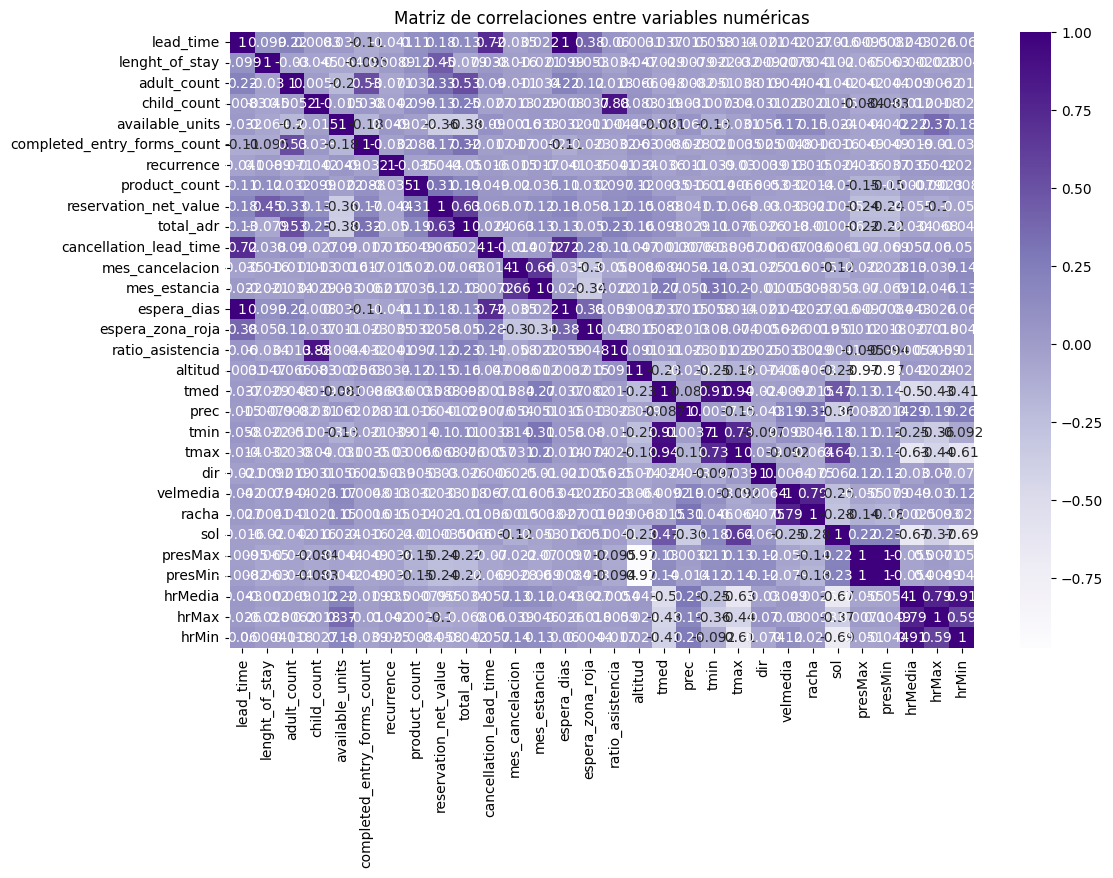

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='Purples', annot=True)
plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()
